# NVIDIA Developer Program — Exploratory Data Analysis

Tables used:
- `activity_clean` — developer engagement events and activity scores
- `contact_clean` — developer profile info (account, geography, interests, lifecycle dates)
- `contact_supplement_clean` — developer geography and industry verticals
- `sdk_download_clean` — aggregate SDK download counts by product and region
- `activity_score_mapping` — scoring weights by activity type (reference)


## 0. Setup & Connect

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

con = duckdb.connect("developer_project.duckdb")

In [2]:
display(con.execute("SHOW TABLES").fetchdf())

,name
0,activity_base
1,activity_clean
2,activity_final
3,activity_raw
4,activity_sample
5,activity_score_mapping_clean
6,activity_score_mapping_raw
7,activity_work
8,contact_clean
9,contact_clean_backup_before_supplement


---
## 1. Table-Level Overview

In [3]:
tables = ['activity_clean', 'contact_clean', 'contact_supplement_clean', 'sdk_download_clean']

for tbl in tables:
    n_rows = con.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    cols = con.execute(f"""
        SELECT column_name FROM information_schema.columns
        WHERE table_name = '{tbl}'
    """).fetchdf()['column_name'].tolist()
    print(f"\n{tbl}:  {n_rows:,} rows | {len(cols)} cols")
    print(" ", cols)


activity_clean:  69,347,526 rows | 16 cols
  ['dev_contact', 'activity', 'activity_name', 'activity_type', 'activity_role', 'activity_attendance', 'activity_score', 'activity_date', 'activity_id', 'filepath', 'pk1', 'pk2', 'lead_source', 'nvidia_campaign_id', 'gtc_nvidia_campaign_id', 'lead_source_details']

contact_clean:  9,381,490 rows | 32 cols
  ['developer_id', 'program_application_source', 'country', 'region', 'sub_region', 'zone', 'territory', 'organization_english_name', 'development_areas', 'other_development_areas', 'industry_segment_vertical', 'other_industry_segment_vertical', 'sub_industry_segment_vertical', 'fields_of_interest', 'other_fields_of_interest', 'first_program_application_date', 'account_id', 'account_name', 'last_activity_date', 'last_modified_date', 'created_date', 'wwfo_category', 'wwfo_target_list', 'account_industry_segment', 'account_source', 'account_type', 'devzone_last_login_date', 'organization_website', 'inception_id', 'first_activity_date', 'norma

---
## 2. Data Quality Checks

### 2a. Duplicate rows

In [5]:
for tbl in tables:
    display(con.execute(f"""
        SELECT
            '{tbl}'  AS table_name,
            COUNT(*) AS total_rows,
            COUNT(*) - (
                SELECT COUNT(*) FROM (SELECT DISTINCT * FROM {tbl})
            ) AS duplicate_rows
        FROM {tbl}
    """).fetchdf())

100% ▕██████████████████████████████████████▏ (00:00:42.30 elapsed)     


,table_name,total_rows,duplicate_rows
0,activity_clean,69347526,163735


100% ▕██████████████████████████████████████▏ (00:00:02.05 elapsed)     


,table_name,total_rows,duplicate_rows
0,contact_clean,9381490,0


,table_name,total_rows,duplicate_rows
0,contact_supplement_clean,478293,0


100% ▕██████████████████████████████████████▏ (00:00:16.33 elapsed)     


,table_name,total_rows,duplicate_rows
0,sdk_download_clean,93038213,275400


### 2b. Duplicate developer_id in contact_clean

In [6]:
display(con.execute("""
    SELECT
        COUNT(*)                                AS total_rows,
        COUNT(DISTINCT developer_id)            AS unique_developer_ids,
        COUNT(*) - COUNT(DISTINCT developer_id) AS duplicate_ids
    FROM contact_clean
""").fetchdf())

,total_rows,unique_developer_ids,duplicate_ids
0,9381490,9381490,0


### 2c. Orphaned activity rows (no matching developer in contact_clean)

In [7]:
display(con.execute("""
    SELECT COUNT(*) AS orphaned_activity_rows
    FROM activity_clean a
    LEFT JOIN contact_clean c ON a.dev_contact = c.developer_id
    WHERE c.developer_id IS NULL
""").fetchdf())

,orphaned_activity_rows
0,2418


---
## 3. Activity Table Analysis

### 3a. Activity type counts

In [8]:
display(con.execute("""
    SELECT activity_type, COUNT(*) AS count
    FROM activity_clean
    GROUP BY activity_type
    ORDER BY count DESC
""").fetchdf())

,activity_type,count
0,Installer,36999321
1,Approved,6654555
2,API Catalog Hosted API,6466203
3,Container,5345238
4,Documentation,1791479
...,...,...
59,true,3
60,image,3
61,NaN,3
62,NVINFO,2


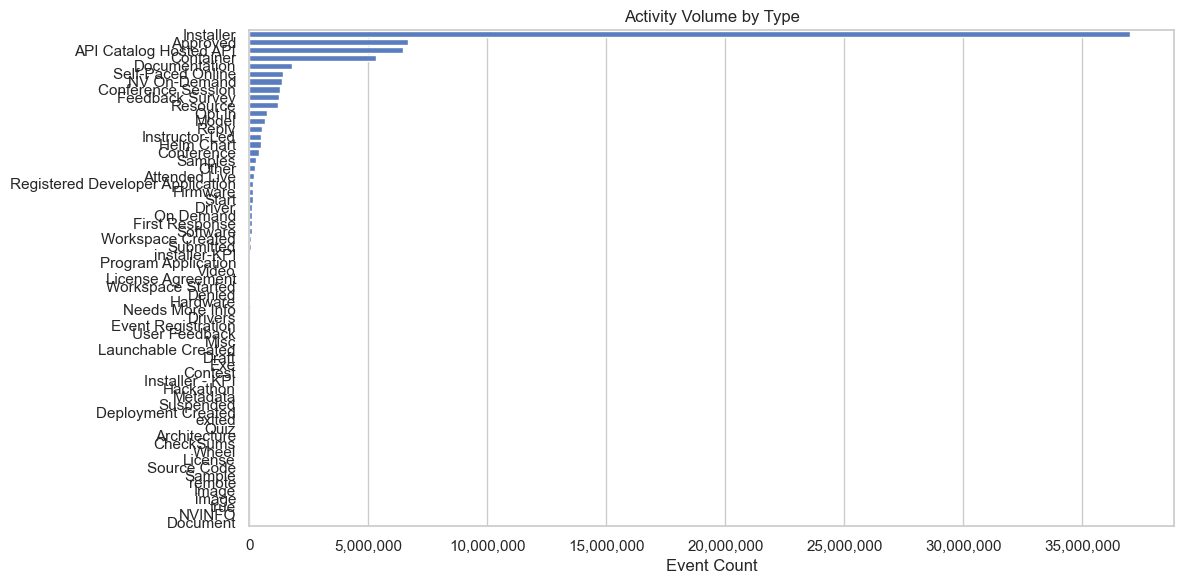

In [9]:
act_type = con.execute("""
    SELECT activity_type, COUNT(*) AS count
    FROM activity_clean
    WHERE activity_type IS NOT NULL
    GROUP BY activity_type
    ORDER BY count DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=act_type, x='count', y='activity_type', ax=ax)
ax.set_title('Activity Volume by Type')
ax.set_xlabel('Event Count')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 3b. Top activity names

In [10]:
display(con.execute("""
    SELECT activity_name, COUNT(*) AS count
    FROM activity_clean
    GROUP BY activity_name
    ORDER BY count DESC
    LIMIT 20
""").fetchdf())

,activity_name,count
0,JetPack SDK,10316702
1,cuDNN,8242287
2,jetpack,7365167
3,Developer,6527784
4,NaN,4940143
5,JetPack,2291461
6,TensorRT,1460465
7,OTHER,1159886
8,cuDNN Download Survey,859540
9,PyTorch,587515


### 3c. Activity score distribution

In [11]:
display(con.execute("""
    SELECT activity_score, COUNT(*) AS count
    FROM activity_clean
    GROUP BY activity_score
    ORDER BY count DESC
""").fetchdf())

,activity_score,count
0,3.0,40386220
1,1.0,10136402
2,0.0,7304120
3,5.0,5173631
4,10.0,1907972
5,20.0,1435932
6,NaN,906358
7,6.0,635828
8,4.0,569597
9,40.0,498176


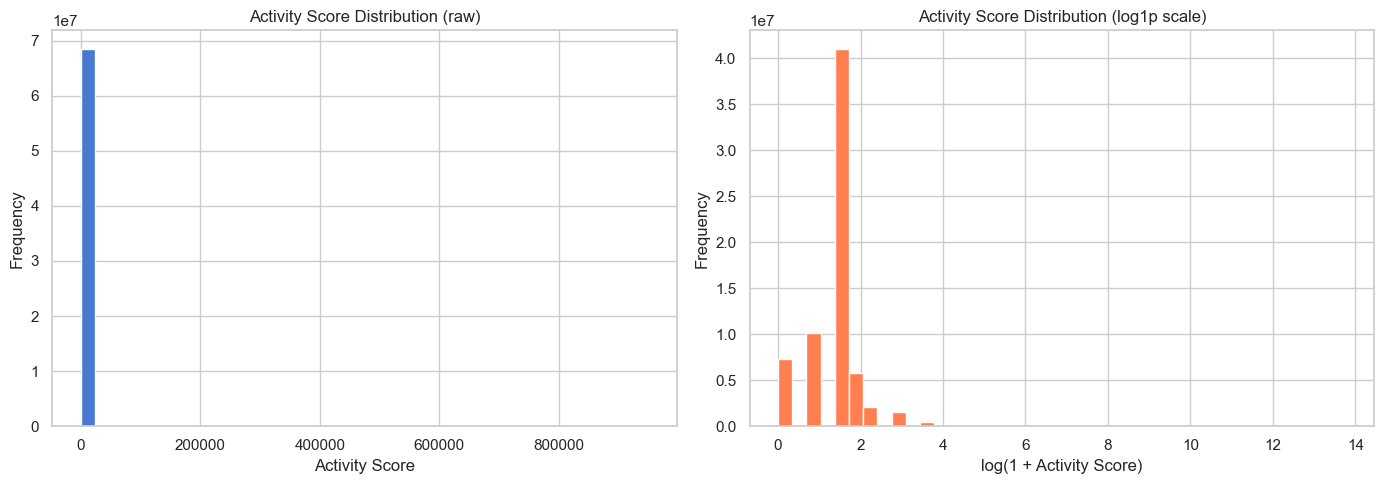

In [12]:
scores = con.execute("""
    SELECT activity_score
    FROM activity_clean
    WHERE activity_score IS NOT NULL
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(scores['activity_score'], bins=40, edgecolor='white')
axes[0].set_title('Activity Score Distribution (raw)')
axes[0].set_xlabel('Activity Score')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(scores['activity_score']), bins=40, edgecolor='white', color='coral')
axes[1].set_title('Activity Score Distribution (log1p scale)')
axes[1].set_xlabel('log(1 + Activity Score)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 3d. Average score per activity type

,activity_type,avg_score,total_score,event_count
0,true,949274.67,2847824.0,3
1,Instructor-Led,40.00,19927040.0,498176
2,Self-Paced Online,20.00,28718640.0,1435932
3,Conference Session,10.80,14180880.0,1312509
4,Conference,9.99,4008575.0,401436
5,Attended Live,9.33,1801362.0,193036
6,Start,8.00,1145864.0,143233
7,First Response,6.73,799489.0,118794
8,Model,6.00,3813773.0,635693
9,Container,5.00,25868156.0,5173632


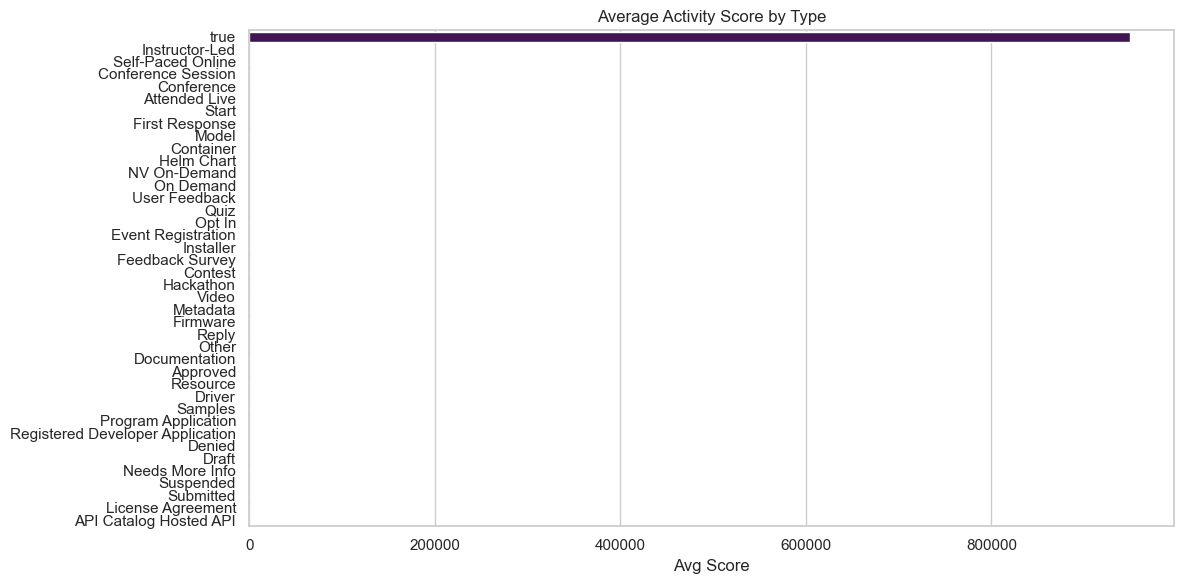

In [13]:
score_by_type = con.execute("""
    SELECT
        activity_type,
        ROUND(AVG(activity_score), 2) AS avg_score,
        ROUND(SUM(activity_score), 0) AS total_score,
        COUNT(*)                      AS event_count
    FROM activity_clean
    WHERE activity_type IS NOT NULL AND activity_score IS NOT NULL
    GROUP BY activity_type
    ORDER BY avg_score DESC
""").fetchdf()

display(score_by_type)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=score_by_type, x='avg_score', y='activity_type', ax=ax, palette='viridis')
ax.set_title('Average Activity Score by Type')
ax.set_xlabel('Avg Score')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 3e. Per-developer engagement totals

In [14]:
display(con.execute("""
    SELECT dev_contact, COUNT(*) AS count
    FROM activity_clean
    GROUP BY dev_contact
    ORDER BY count DESC
    LIMIT 10
""").fetchdf())

,dev_contact,count
0,5903679,2027375
1,5886356,789400
2,3931685,187095
3,1303597,151947
4,2028858,142980
5,6309430,121950
6,4634152,107089
7,6125204,68992
8,4833930,55061
9,225774,53677


100% ▕██████████████████████████████████████▏ (00:00:02.33 elapsed)     
 99% ▕█████████████████████████████████████▌▏ (<1 second remaining)     

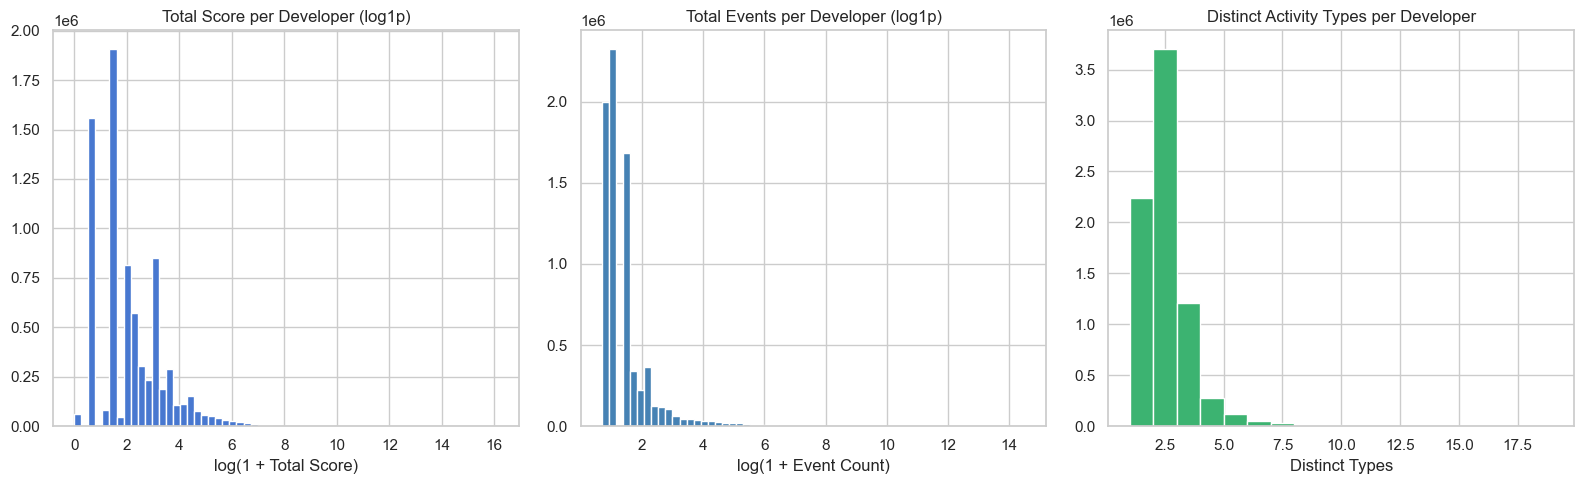

        total_score  total_events  distinct_types
count  7.629591e+06  7.660279e+06    7.660279e+06
mean   3.127490e+01  9.052872e+00    2.071797e+00
std    4.072913e+03  8.000512e+02    1.144478e+00
min    0.000000e+00  1.000000e+00    1.000000e+00
25%    3.000000e+00  1.000000e+00    1.000000e+00
50%    7.000000e+00  2.000000e+00    2.000000e+00
75%    2.000000e+01  4.000000e+00    2.000000e+00
max    1.001513e+07  2.027375e+06    3.000000e+01


In [15]:
dev_totals = con.execute("""
    SELECT
        dev_contact,
        SUM(activity_score)           AS total_score,
        COUNT(*)                      AS total_events,
        COUNT(DISTINCT activity_type) AS distinct_types
    FROM activity_clean
    GROUP BY dev_contact
""").fetchdf()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(np.log1p(dev_totals['total_score']), bins=60, edgecolor='white')
axes[0].set_title('Total Score per Developer (log1p)')
axes[0].set_xlabel('log(1 + Total Score)')

axes[1].hist(np.log1p(dev_totals['total_events']), bins=60, edgecolor='white', color='steelblue')
axes[1].set_title('Total Events per Developer (log1p)')
axes[1].set_xlabel('log(1 + Event Count)')

axes[2].hist(dev_totals['distinct_types'], bins=range(1, 20), edgecolor='white', color='mediumseagreen')
axes[2].set_title('Distinct Activity Types per Developer')
axes[2].set_xlabel('Distinct Types')

plt.tight_layout()
plt.show()

print(dev_totals[['total_score', 'total_events', 'distinct_types']].describe())

### 3f. Engagement breadth vs. depth

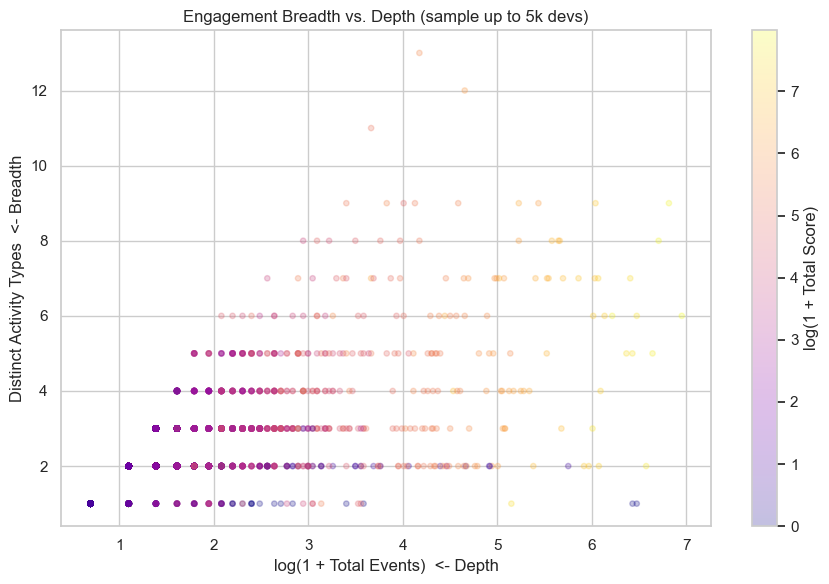

In [16]:
sample = dev_totals.sample(min(5000, len(dev_totals)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    np.log1p(sample['total_events']),
    sample['distinct_types'],
    alpha=0.25, s=15,
    c=np.log1p(sample['total_score']), cmap='plasma'
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('log(1 + Total Score)')
ax.set_title('Engagement Breadth vs. Depth (sample up to 5k devs)')
ax.set_xlabel('log(1 + Total Events)  <- Depth')
ax.set_ylabel('Distinct Activity Types  <- Breadth')
plt.tight_layout()
plt.show()

### 3g. Activity trend over time

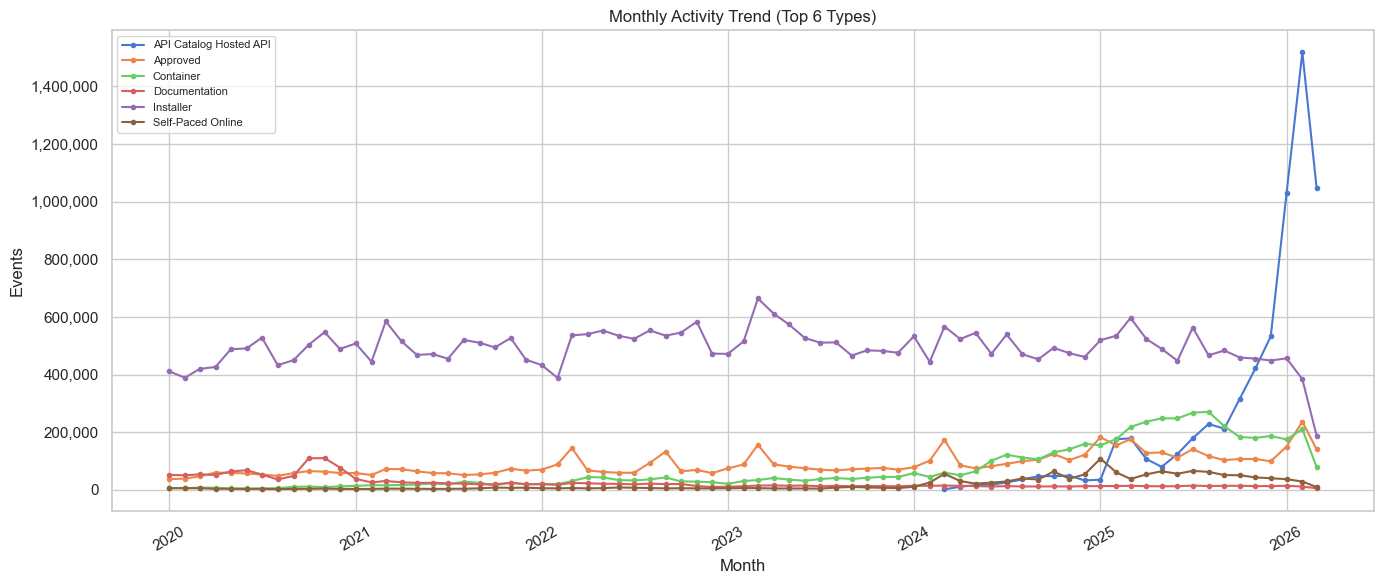

In [17]:
act_trend = con.execute("""
    SELECT
        DATE_TRUNC('month', activity_date) AS month,
        activity_type,
        COUNT(*)                           AS events
    FROM activity_clean
    WHERE activity_date IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 1
""").fetchdf()

top6_types = act_type['activity_type'].head(6).tolist()
trend_filtered = act_trend[act_trend['activity_type'].isin(top6_types)]

fig, ax = plt.subplots(figsize=(14, 6))
for atype, grp in trend_filtered.groupby('activity_type'):
    ax.plot(grp['month'], grp['events'], label=atype, lw=1.5, marker='o', markersize=3)
ax.set_title('Monthly Activity Trend (Top 6 Types)')
ax.set_xlabel('Month')
ax.set_ylabel('Events')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 4. Contact Table Analysis

### 4a. Developer growth over time

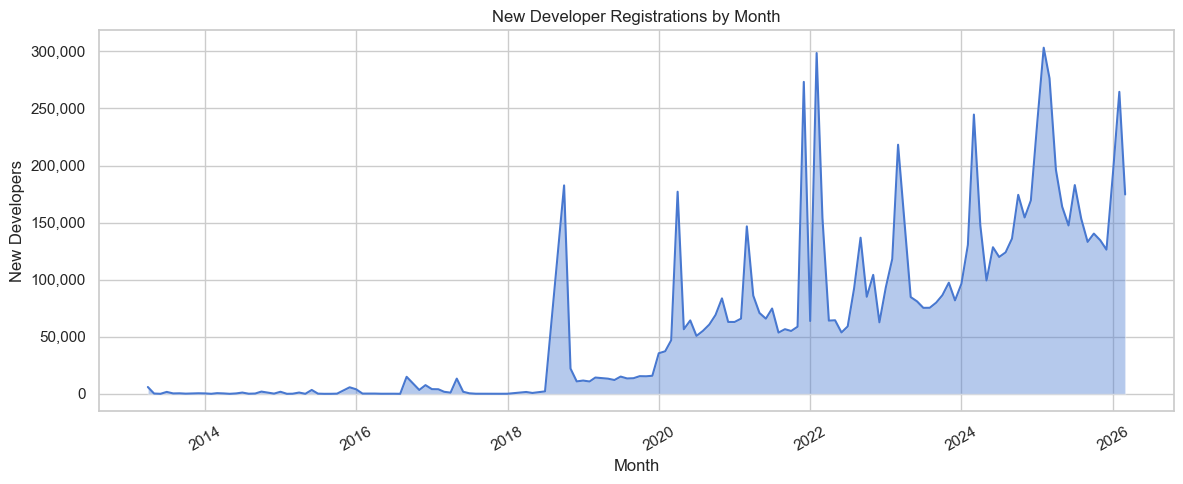

In [18]:
growth = con.execute("""
    SELECT
        DATE_TRUNC('month', created_date) AS month,
        COUNT(*)                          AS new_developers
    FROM contact_clean
    WHERE created_date IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

fig, ax = plt.subplots()
ax.fill_between(growth['month'], growth['new_developers'], alpha=0.4)
ax.plot(growth['month'], growth['new_developers'], lw=1.5)
ax.set_title('New Developer Registrations by Month')
ax.set_xlabel('Month')
ax.set_ylabel('New Developers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 4b. RDP membership split

,rdp_status,developers
0,RDP Member,6792339
1,Non-RDP,2589151


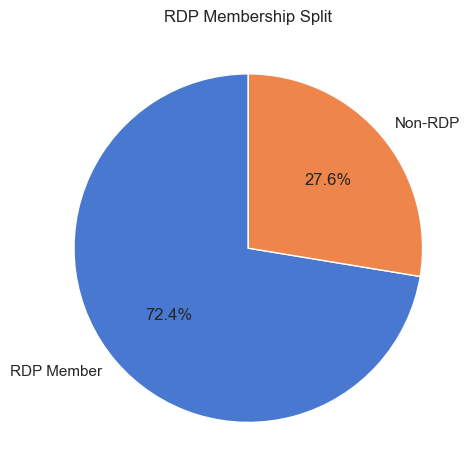

In [19]:
rdp = con.execute("""
    SELECT
        CASE WHEN first_program_application_date IS NOT NULL THEN 'RDP Member'
             ELSE 'Non-RDP'
        END AS rdp_status,
        COUNT(*) AS developers
    FROM contact_clean
    GROUP BY 1
""").fetchdf()

display(rdp)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(rdp['developers'], labels=rdp['rdp_status'], autopct='%1.1f%%', startangle=90)
ax.set_title('RDP Membership Split')
plt.tight_layout()
plt.show()

### 4c. Top program application sources

,program_application_source,developers
0,null,4006295
1,devzone,2806574
2,dli,1004037
3,gtc,448297
4,api_catalog,391786
5,GTC Fall 2022,107396
6,GTC Spring 2022,89807
7,nod,46301
8,brev,10869
9,inception,9213


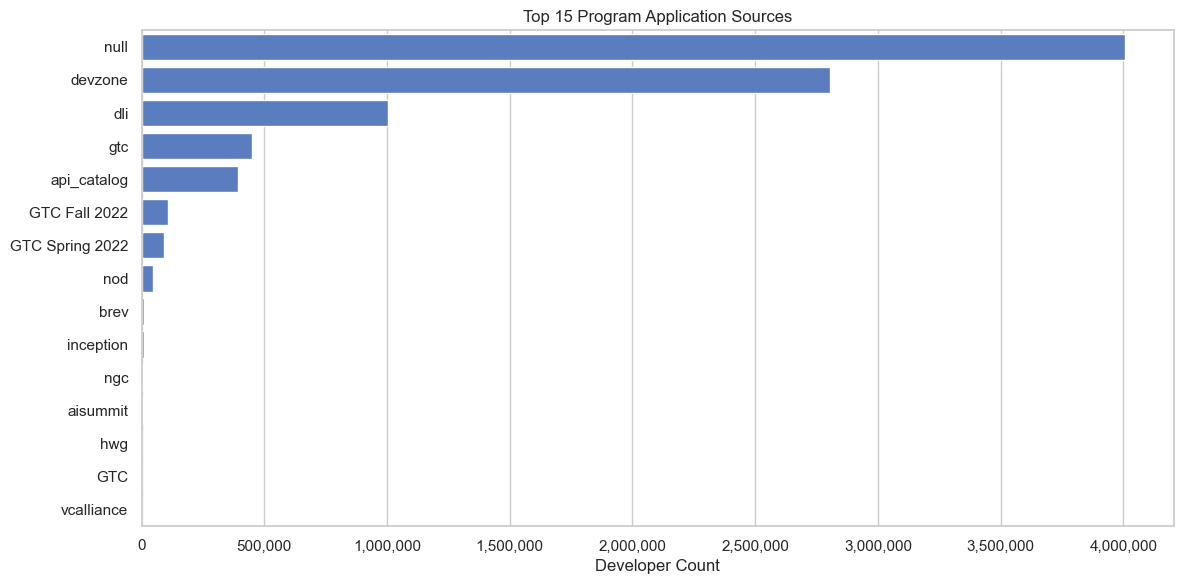

In [20]:
sources = con.execute("""
    SELECT
        program_application_source,
        COUNT(*) AS developers
    FROM contact_clean
    WHERE program_application_source IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 15
""").fetchdf()

display(sources)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=sources, x='developers', y='program_application_source', ax=ax)
ax.set_title('Top 15 Program Application Sources')
ax.set_xlabel('Developer Count')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 4d. Account type distribution (multi-select expanded)

,account_type,developers
0,University,1980017
1,Enterprise,740459
2,Startup,215987
3,Enterprise;University,16654
4,Startup;University,12856
5,Enterprise;Startup,11388


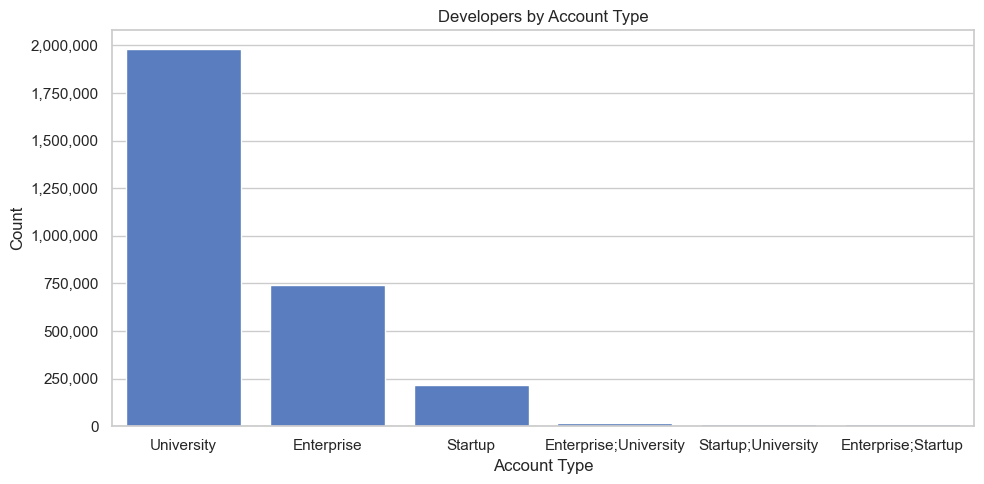

In [21]:
acct_type = con.execute("""
    SELECT
        TRIM(type_value) AS account_type,
        COUNT(*)         AS developers
    FROM (
        SELECT UNNEST(STRING_SPLIT(account_type, ',')) AS type_value
        FROM contact_clean
        WHERE account_type IS NOT NULL
    )
    GROUP BY 1
    ORDER BY 2 DESC
""").fetchdf()

display(acct_type)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=acct_type, x='account_type', y='developers', ax=ax)
ax.set_title('Developers by Account Type')
ax.set_xlabel('Account Type')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 4e. DevZone last login recency

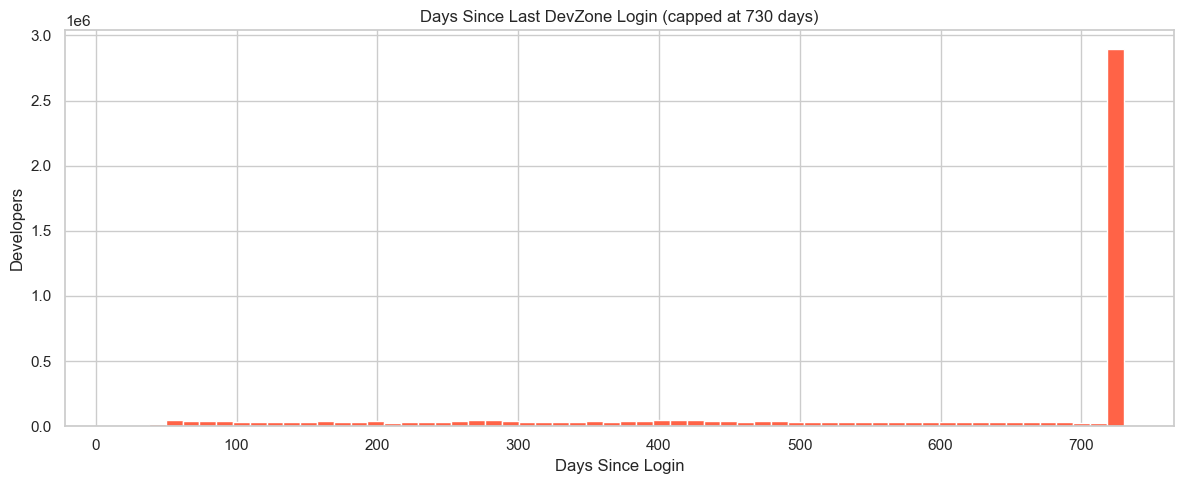

count    4.921007e+06
mean     9.869786e+02
std      6.409068e+02
min      1.400000e+01
25%      4.340000e+02
50%      8.920000e+02
75%      1.483000e+03
max      5.499000e+03
Name: days_since_login, dtype: float64


In [22]:
recency = con.execute("""
    SELECT
        DATEDIFF('day', devzone_last_login_date, CURRENT_DATE) AS days_since_login
    FROM contact_clean
    WHERE devzone_last_login_date IS NOT NULL
""").fetchdf()

fig, ax = plt.subplots()
ax.hist(recency['days_since_login'].clip(0, 730), bins=60, edgecolor='white', color='tomato')
ax.set_title('Days Since Last DevZone Login (capped at 730 days)')
ax.set_xlabel('Days Since Login')
ax.set_ylabel('Developers')
plt.tight_layout()
plt.show()

print(recency['days_since_login'].describe())

---
## 5. Contact Supplement — Geography & Industry

### 5a. Top 20 countries

,country,developers
0,China,105396
1,United States,91606
2,Japan,30175
3,"Korea, Republic of",27177
4,Germany,20161
5,India,17781
6,Taiwan,16379
7,United Kingdom,13906
8,Canada,11681
9,Russian Federation,10229


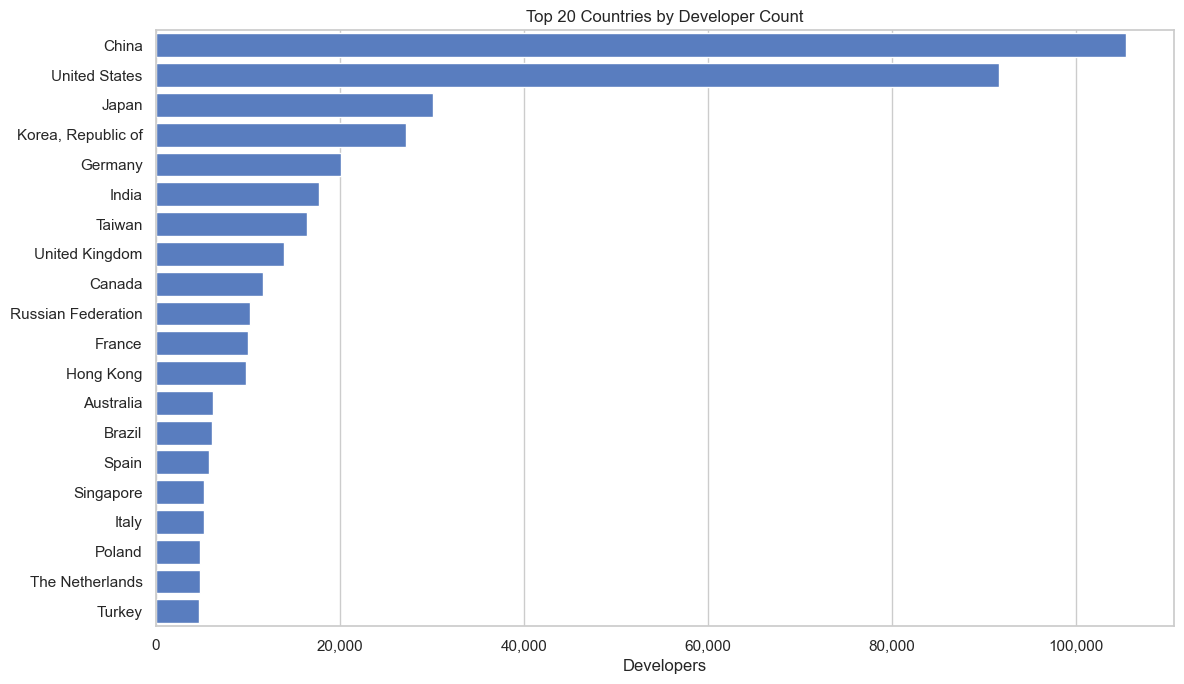

In [23]:
countries = con.execute("""
    SELECT
        country,
        COUNT(DISTINCT developer_id) AS developers
    FROM contact_supplement_clean
    WHERE country IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 20
""").fetchdf()

display(countries)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=countries, x='developers', y='country', ax=ax)
ax.set_title('Top 20 Countries by Developer Count')
ax.set_xlabel('Developers')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 5b. Developers by region

,region,developers
0,APAC,232118
1,EMEA,126723
2,NALA,116611


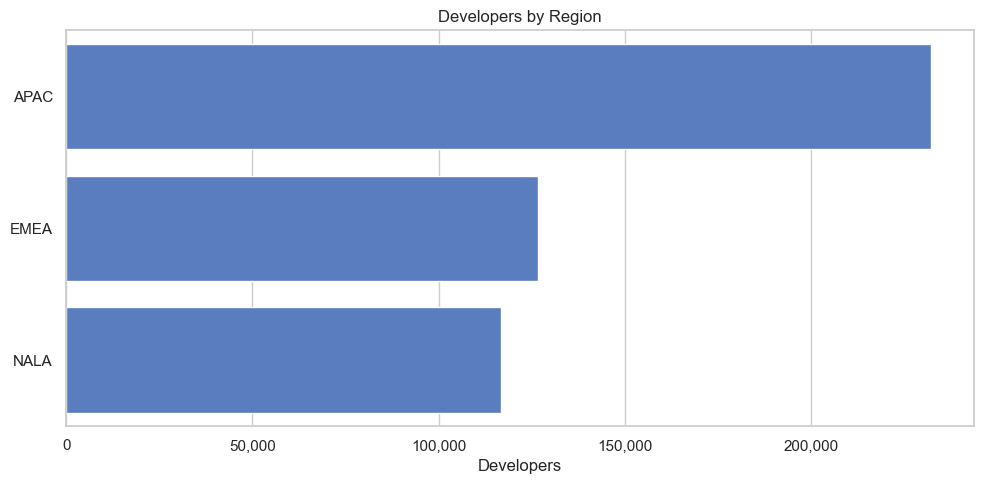

In [24]:
regions = con.execute("""
    SELECT
        region,
        COUNT(DISTINCT developer_id) AS developers
    FROM contact_supplement_clean
    WHERE region IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
""").fetchdf()

display(regions)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=regions, x='developers', y='region', ax=ax)
ax.set_title('Developers by Region')
ax.set_xlabel('Developers')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 5c. Top 20 industry verticals

,industry_segment_vertical,developers
0,Other,231617
1,Academia / Education,54920
2,Gaming,33889
3,AEC,25839
4,Automotive / Transportation,17193
5,Healthcare & Life Sciences,14424
6,Media & Entertainment,14384
7,Hardware / Semiconductor,12162
8,Manufacturing,10602
9,Cloud Services,9913


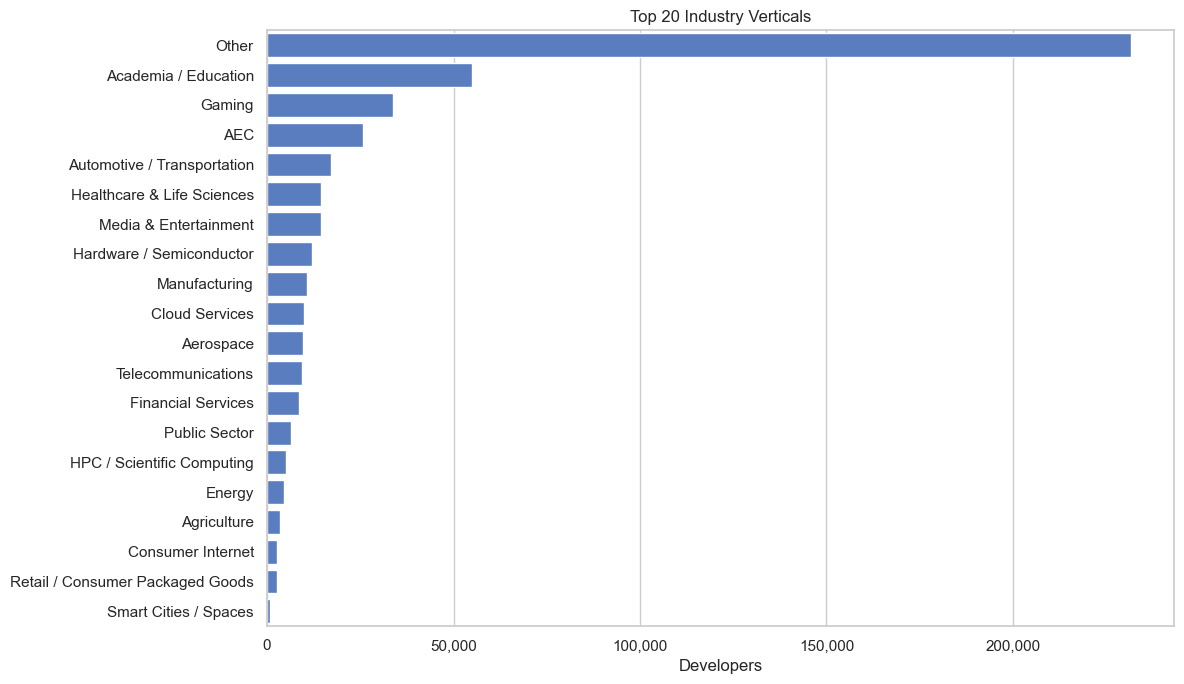

In [25]:
industry = con.execute("""
    SELECT
        industry_segment_vertical,
        COUNT(DISTINCT developer_id) AS developers
    FROM contact_supplement_clean
    WHERE industry_segment_vertical IS NOT NULL
      AND industry_segment_vertical != ''
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 20
""").fetchdf()

display(industry)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=industry, x='developers', y='industry_segment_vertical', ax=ax)
ax.set_title('Top 20 Industry Verticals')
ax.set_xlabel('Developers')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## 6. Cross-Table Insights

### 6a. Avg engagement score by region

,region,developers,avg_total_score,avg_events
0,NALA,115742,107.9,30.9
1,APAC,231186,81.2,26.6
2,EMEA,126273,73.2,22.9


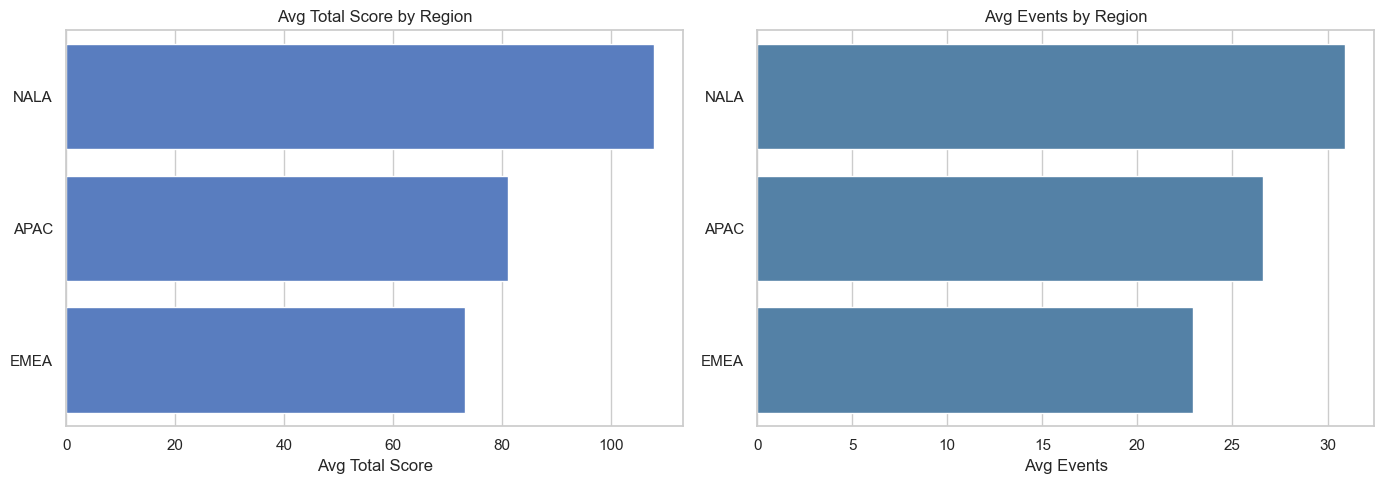

In [26]:
region_score = con.execute("""
    SELECT
        s.region,
        COUNT(DISTINCT c.developer_id)         AS developers,
        ROUND(AVG(dev_totals.total_score), 1)  AS avg_total_score,
        ROUND(AVG(dev_totals.total_events), 1) AS avg_events
    FROM contact_clean c
    JOIN contact_supplement_clean s ON c.developer_id = s.developer_id
    JOIN (
        SELECT dev_contact,
               SUM(activity_score) AS total_score,
               COUNT(*)            AS total_events
        FROM activity_clean
        GROUP BY dev_contact
    ) dev_totals ON c.developer_id = dev_totals.dev_contact
    WHERE s.region IS NOT NULL
    GROUP BY 1
    ORDER BY avg_total_score DESC
""").fetchdf()

display(region_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=region_score, x='avg_total_score', y='region', ax=axes[0])
axes[0].set_title('Avg Total Score by Region')
axes[0].set_xlabel('Avg Total Score')
axes[0].set_ylabel('')

sns.barplot(data=region_score, x='avg_events', y='region', ax=axes[1], color='steelblue')
axes[1].set_title('Avg Events by Region')
axes[1].set_xlabel('Avg Events')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 6b. RDP vs. non-RDP engagement

In [27]:
rdp_eng = con.execute("""
    SELECT
        CASE WHEN c.first_program_application_date IS NOT NULL THEN 'RDP Member'
             ELSE 'Non-RDP'
        END AS rdp_status,
        COUNT(DISTINCT c.developer_id)           AS developers,
        ROUND(AVG(dev_totals.total_score), 1)    AS avg_total_score,
        ROUND(AVG(dev_totals.total_events), 1)   AS avg_events,
        ROUND(AVG(dev_totals.distinct_types), 1) AS avg_distinct_types
    FROM contact_clean c
    JOIN (
        SELECT dev_contact,
               SUM(activity_score)           AS total_score,
               COUNT(*)                      AS total_events,
               COUNT(DISTINCT activity_type) AS distinct_types
        FROM activity_clean
        GROUP BY dev_contact
    ) dev_totals ON c.developer_id = dev_totals.dev_contact
    GROUP BY 1
""").fetchdf()

display(rdp_eng)

100% ▕██████████████████████████████████████▏ (00:00:02.75 elapsed)     


,rdp_status,developers,avg_total_score,avg_events,avg_distinct_types
0,Non-RDP,882824,17.8,4.9,1.2
1,RDP Member,6777436,32.6,9.6,2.2


### 6c. Avg engagement by account type

,account_type,developers,avg_total_score
0,Enterprise,602393,81.9
1,Enterprise;Startup,9990,48.3
2,Startup,200042,45.3
3,Startup;University,11983,31.4
4,Enterprise;University,15389,28.6
5,University,1856998,23.4


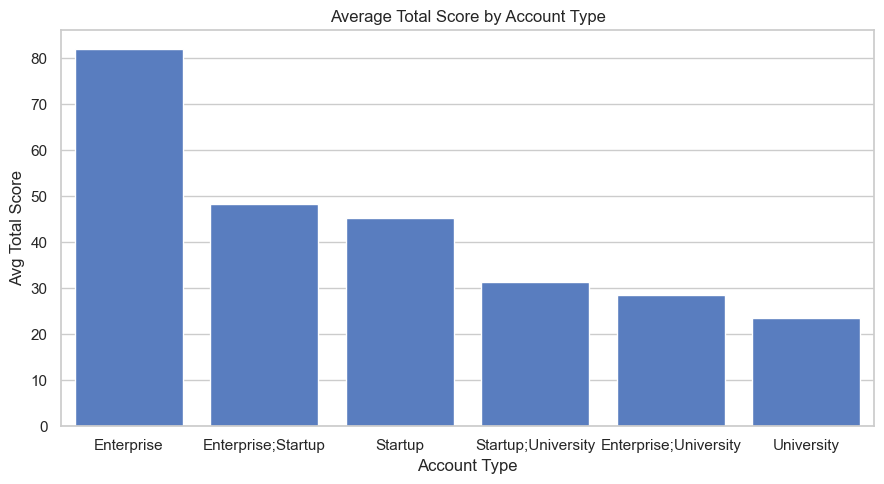

In [28]:
acct_eng = con.execute("""
    SELECT
        TRIM(type_value)                      AS account_type,
        COUNT(DISTINCT c.developer_id)        AS developers,
        ROUND(AVG(dev_totals.total_score), 1) AS avg_total_score
    FROM (
        SELECT developer_id,
               UNNEST(STRING_SPLIT(account_type, ',')) AS type_value
        FROM contact_clean
        WHERE account_type IS NOT NULL
    ) c
    JOIN (
        SELECT dev_contact, SUM(activity_score) AS total_score
        FROM activity_clean
        GROUP BY dev_contact
    ) dev_totals ON c.developer_id = dev_totals.dev_contact
    GROUP BY 1
    ORDER BY avg_total_score DESC
""").fetchdf()

display(acct_eng)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=acct_eng, x='account_type', y='avg_total_score', ax=ax)
ax.set_title('Average Total Score by Account Type')
ax.set_xlabel('Account Type')
ax.set_ylabel('Avg Total Score')
plt.tight_layout()
plt.show()

### 6d. Top 10 most engaged developers (champion detection)

In [29]:
display(con.execute("""
    SELECT
        a.dev_contact                      AS developer_id,
        c.normalized_account_name,
        s.country,
        s.region,
        SUM(a.activity_score)             AS total_score,
        COUNT(*)                          AS total_events,
        COUNT(DISTINCT a.activity_type)   AS distinct_types,
        MIN(a.activity_date)              AS first_activity,
        MAX(a.activity_date)              AS last_activity
    FROM activity_clean a
    JOIN contact_clean c ON a.dev_contact = c.developer_id
    LEFT JOIN contact_supplement_clean s ON a.dev_contact = s.developer_id
    GROUP BY 1, 2, 3, 4
    ORDER BY total_score DESC
    LIMIT 10
""").fetchdf())

100% ▕██████████████████████████████████████▏ (00:00:14.46 elapsed)     


,developer_id,normalized_account_name,country,region,total_score,total_events,distinct_types,first_activity,last_activity
0,5903679,NVIDIA,NaN,NaN,10015132.0,2027375,5,2021-03-04 00:00:00,2026-03-12
1,5886356,Straitdeer Pte Ltd,NaN,NaN,3946993.0,789400,5,2024-03-04 03:22:47,2026-03-12
2,3931685,Onfido,NaN,NaN,934975.0,187095,1,2023-07-04 00:00:00,2026-03-03
3,2028858,University of Missouri,United States,NALA,714100.0,142980,1,2022-03-12 00:00:00,2026-03-12
4,1303597,NVIDIA,India,APAC,449262.0,151947,12,2020-01-02 00:00:00,2026-03-08
5,6125204,Not Normalized,NaN,NaN,344958.0,68992,15,2020-04-17 00:00:00,2026-02-12
6,4833930,NVIDIA,NaN,NaN,275414.0,55061,3,2024-05-24 00:00:00,2024-11-06
7,225774,Paige ai,NaN,NaN,267525.0,53677,1,2021-03-11 00:00:00,2022-10-04
8,6309430,NVIDIA,NaN,NaN,233315.0,121950,9,2020-03-20 00:00:00,2026-03-11
9,5671110,NVIDIA,NaN,NaN,198000.0,49514,1,2023-03-31 00:00:00,2026-03-12


### 6e. Cohort retention heatmap

100% ▕██████████████████████████████████████▏ (00:00:02.48 elapsed)     


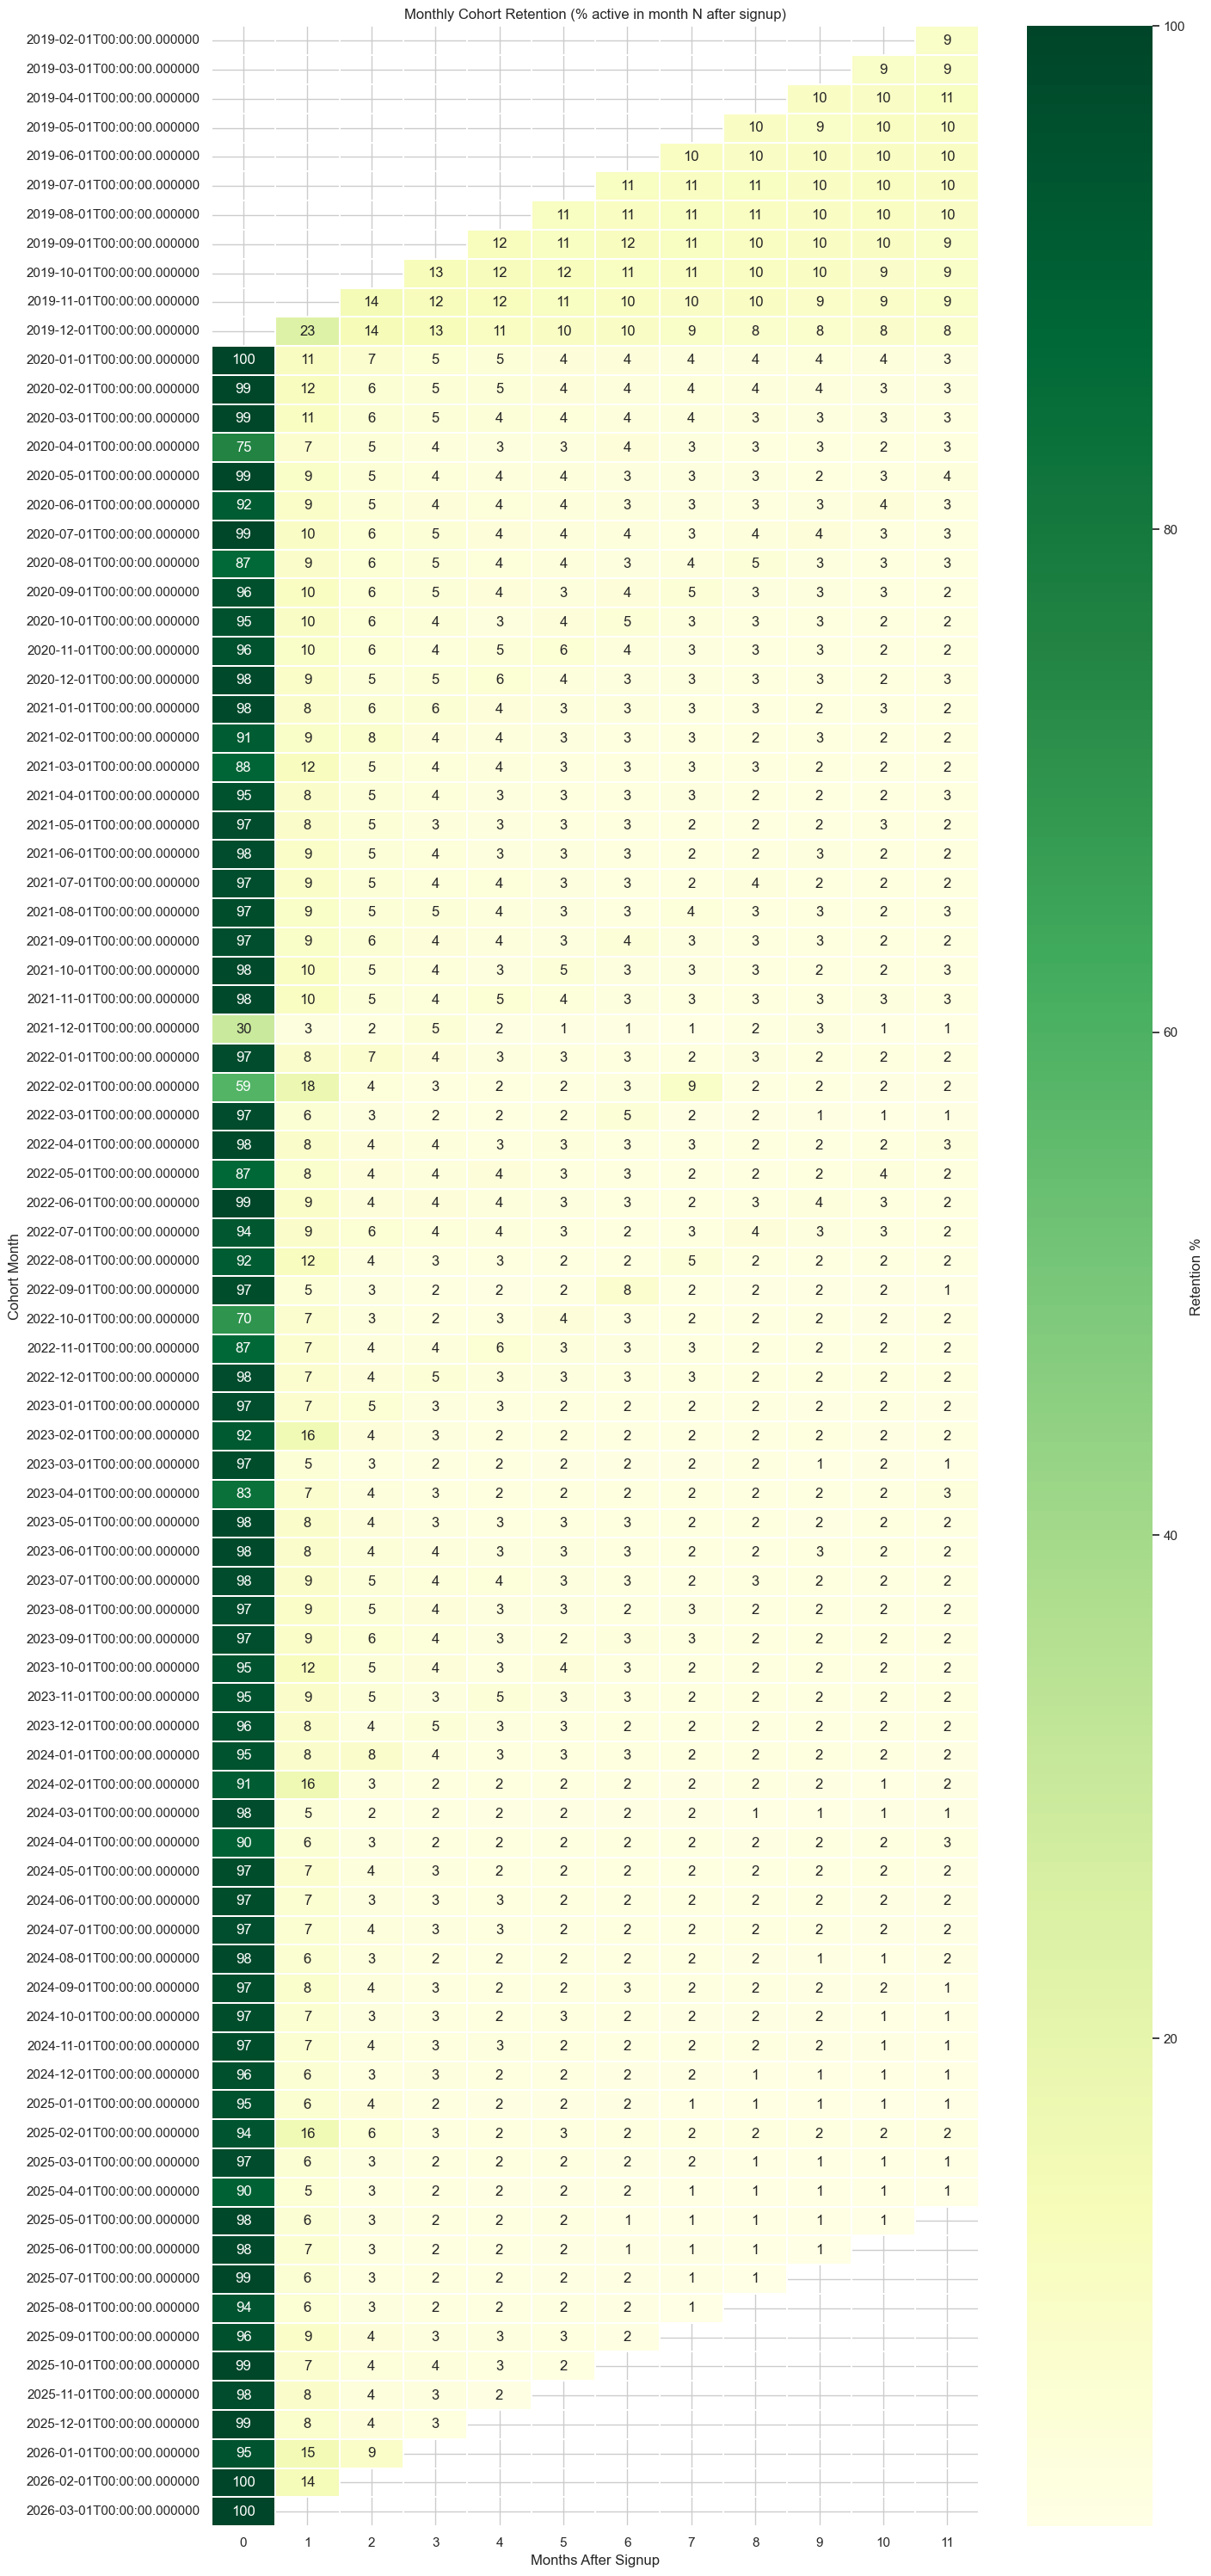

In [30]:
cohort = con.execute("""
    WITH base AS (
        SELECT
            c.developer_id,
            DATE_TRUNC('month', c.created_date)  AS cohort_month,
            DATE_TRUNC('month', a.activity_date) AS act_month
        FROM contact_clean c
        JOIN activity_clean a ON c.developer_id = a.dev_contact
        WHERE c.created_date IS NOT NULL AND a.activity_date IS NOT NULL
    ),
    sizes AS (
        SELECT cohort_month, COUNT(DISTINCT developer_id) AS cohort_size
        FROM base GROUP BY cohort_month
    ),
    monthly AS (
        SELECT
            cohort_month,
            DATEDIFF('month', cohort_month, act_month) AS months_after,
            COUNT(DISTINCT developer_id) AS active
        FROM base
        WHERE DATEDIFF('month', cohort_month, act_month) BETWEEN 0 AND 11
        GROUP BY 1, 2
    )
    SELECT
        m.cohort_month,
        m.months_after,
        ROUND(m.active * 100.0 / s.cohort_size, 1) AS retention_pct
    FROM monthly m
    JOIN sizes s ON m.cohort_month = s.cohort_month
    ORDER BY 1, 2
""").fetchdf()

pivot = cohort.pivot(index='cohort_month', columns='months_after', values='retention_pct')

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.35)))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGn',
            linewidths=0.3, cbar_kws={'label': 'Retention %'}, ax=ax)
ax.set_title('Monthly Cohort Retention (% active in month N after signup)')
ax.set_xlabel('Months After Signup')
ax.set_ylabel('Cohort Month')
plt.tight_layout()
plt.show()

---
## 7. SDK Download Analysis

### 7a. Preview and columns

In [31]:
display(con.execute("SUMMARIZE sdk_download_clean").fetchdf())

100% ▕██████████████████████████████████████▏ (00:00:04.71 elapsed)     


,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,source,VARCHAR,CDN,VSCODE,13,NaN,NaN,NaN,NaN,NaN,93038213,0.00
1,sdk_name,VARCHAR,3DGRUT,tensorflow_products,218,NaN,NaN,NaN,NaN,NaN,93038213,1.37
2,product_name,VARCHAR,(Linux) Acoustic Echo Cancellation,warp-lang,1183,NaN,NaN,NaN,NaN,NaN,93038213,0.00
3,product_release,VARCHAR,0.0,zjyu7g90o5jt/cosmos-1-0-diffusion-7b-text2worl...,11842,NaN,NaN,NaN,NaN,NaN,93038213,1.39
4,country,VARCHAR,AD,ZW,294,NaN,NaN,NaN,NaN,NaN,93038213,1.35
5,region,VARCHAR,APAC,NALA,3,NaN,NaN,NaN,NaN,NaN,93038213,1.35
6,subregion,VARCHAR,Africa,US & Canada,12,NaN,NaN,NaN,NaN,NaN,93038213,1.35
7,territory,VARCHAR,AFRICA,UK_NORDICS,17,NaN,NaN,NaN,NaN,NaN,93038213,42.43
8,zone,VARCHAR,ANZ,Western Europe,20,NaN,NaN,NaN,NaN,NaN,93038213,1.35
9,download_date,DATE,2020-01-01,2026-03-12,2293,2024-05-01 18:07:15.390675,NaN,2023-06-08,2024-10-09,2025-07-25,93038213,0.00


In [32]:
display(con.execute("""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_name = 'sdk_download_raw'
""").fetchdf())

,column_name
0,source
1,sdk_name
2,PRODUCTNAME
3,PRODUCTRELEASE
4,country
5,region
6,subregion
7,territory
8,zone
9,downloaddate


### 7b. Duplicate check

In [33]:
# Check duplicates
display(con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(*) - (
            SELECT COUNT(*) FROM (SELECT DISTINCT * FROM sdk_download_clean)
        ) AS duplicate_rows
    FROM sdk_download_clean
""").fetchdf())

100% ▕██████████████████████████████████████▏ (00:00:17.16 elapsed)     


,total_rows,duplicate_rows
0,93038213,275400


### 7c. Downloads by source
*(Review column names from 7a and adjust below if needed)*

,source,total_downloads
0,PyPi,1.449660e+10
1,GitHub,2.886507e+08
2,CDN,1.134670e+08
3,NGC,1.066840e+08
4,DOCKERHUB,8.524674e+07
5,Conda,4.547801e+07
6,CDN - PyPI,2.358220e+07
7,Huggingface,5.801805e+06
8,CDN - Azure,8.755900e+05
9,CDN - APT,7.984240e+05


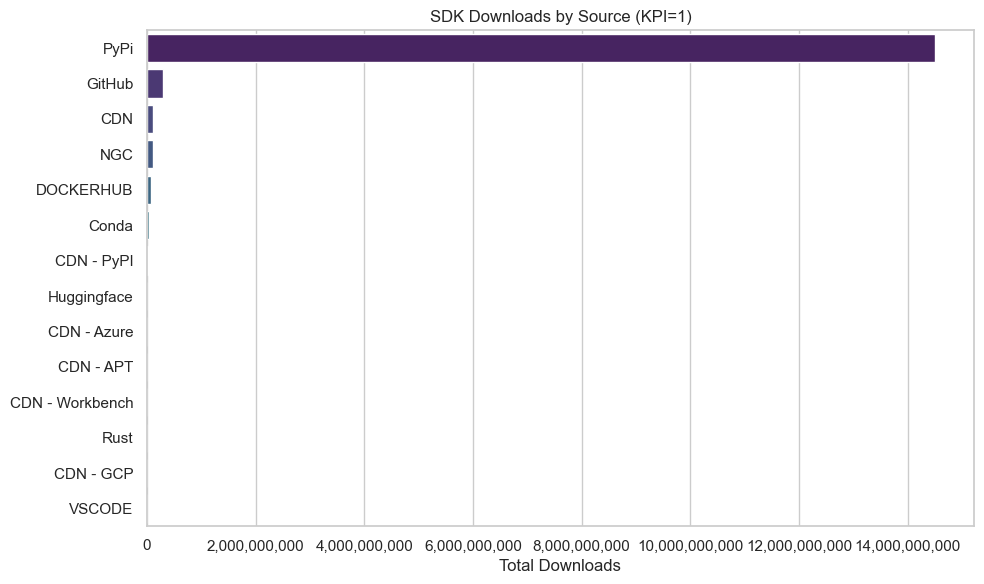

In [42]:
sdk_by_source = con.execute("""
    SELECT
        source,
        SUM(download_count) AS total_downloads
    FROM sdk_download_clean
    WHERE KPI = 1
      AND source IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
""").fetchdf()

display(sdk_by_source)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=sdk_by_source, x='total_downloads', y='source', ax=ax, palette='viridis')
ax.set_title('SDK Downloads by Source (KPI=1)')
ax.set_xlabel('Total Downloads')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 7d. SDK download trend over time

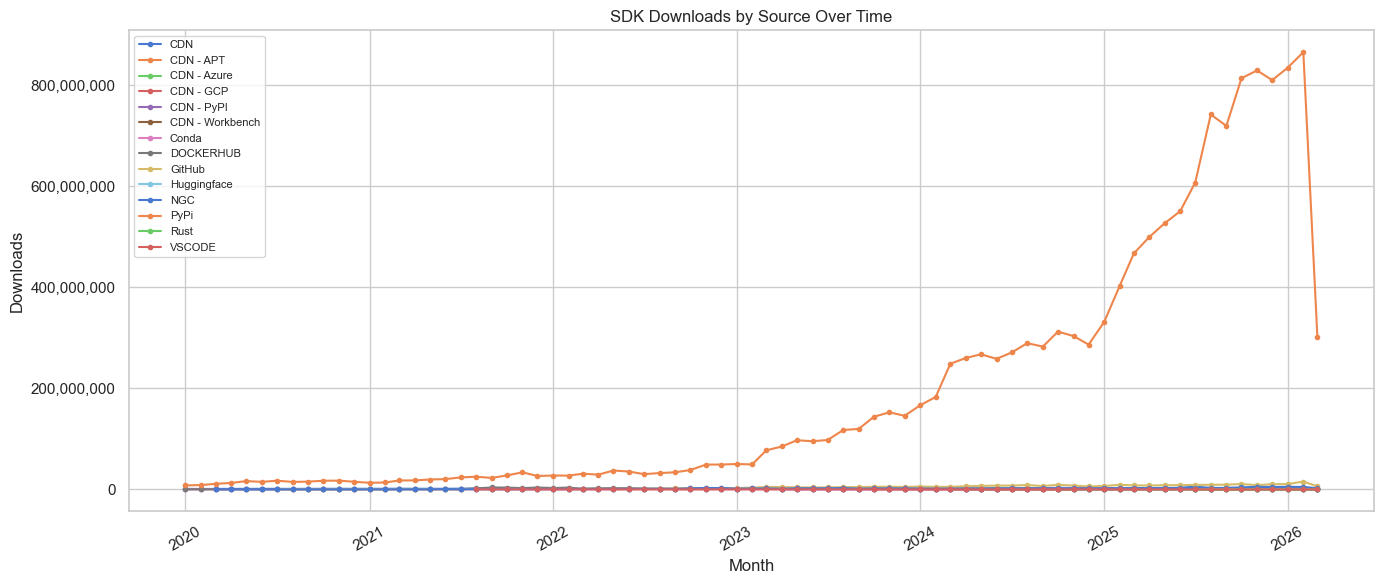

In [45]:
sdk_trend = con.execute("""
    SELECT
        DATE_TRUNC('month', download_date) AS month,
        source,
        SUM(download_count)               AS downloads
    FROM sdk_download_clean
    WHERE KPI = 1
      AND download_date IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 1
""").fetchdf()

fig, ax = plt.subplots(figsize=(14, 6))
for src, grp in sdk_trend.groupby('source'):
    ax.plot(grp['month'], grp['downloads'], label=src, lw=1.5, marker='o', markersize=3)
ax.set_title('SDK Downloads by Source Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Downloads')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=8, loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 8. Activity Score Mapping Reference

,object,field,value,score
0,Dev Event Attendance,Role,Presenter/Speaker,100
1,Dev Form,Form Type,Testimonial,50
2,Dev DLI Attendance,Course Type,Instructor-Led,40
3,Dev DLI Attendance,Course Type,Instructor-Led Remote,30
4,Dev DLI Attendance,Course Type,Self-Paced Online,20
5,Dev Forum Activities,Accepted Date,TRUE,15
6,Dev Event,Event Type,Conference,10
7,Dev DLI Attendance,Course Type,Third party,10
8,Dev Event,Event Type,Conference Session,10
9,Dev Event Attendance,Status,Attended Live,10


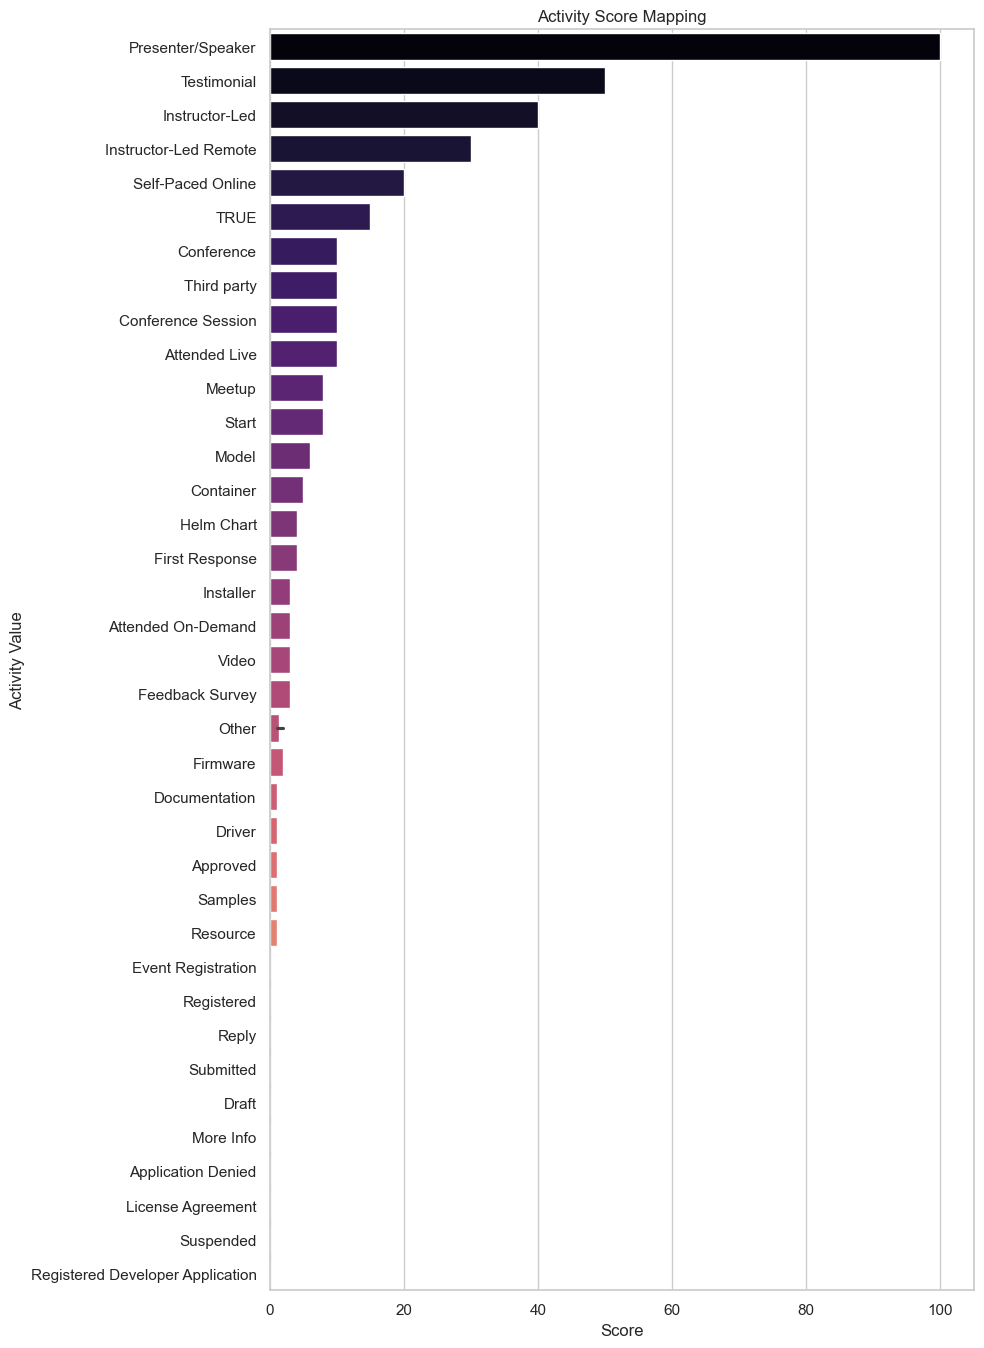

In [39]:
try:
    score_map = con.execute("""
        SELECT * FROM activity_score_mapping_raw
        ORDER BY score DESC
    """).fetchdf()
    display(score_map)

    fig, ax = plt.subplots(figsize=(10, max(5, len(score_map) * 0.35)))
    sns.barplot(data=score_map, x='score', y='value', ax=ax, palette='magma')
    ax.set_title('Activity Score Mapping')
    ax.set_xlabel('Score')
    ax.set_ylabel('Activity Value')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'activity_score_mapping not found or column names differ: {e}')

---
## 9. EDA Summary

In [40]:
total_devs   = con.execute("SELECT COUNT(DISTINCT developer_id) FROM contact_clean").fetchone()[0]
total_events = con.execute("SELECT COUNT(*) FROM activity_clean").fetchone()[0]
rdp_count    = con.execute(
    "SELECT COUNT(*) FROM contact_clean WHERE first_program_application_date IS NOT NULL"
).fetchone()[0]
top_act = con.execute(
    "SELECT activity_type FROM activity_clean GROUP BY activity_type ORDER BY COUNT(*) DESC LIMIT 1"
).fetchone()[0]
top_country = con.execute(
    "SELECT country FROM contact_supplement_clean WHERE country IS NOT NULL GROUP BY country ORDER BY COUNT(*) DESC LIMIT 1"
).fetchone()[0]

print("=" * 55)
print("  EDA SUMMARY")
print("=" * 55)
print(f"  Total developers:          {total_devs:>10,}")
print(f"  Total activity events:     {total_events:>10,}")
print(f"  RDP members:               {rdp_count:>10,}  ({rdp_count/total_devs*100:.1f}%)")
print(f"  Most common activity type: {top_act}")
print(f"  Top country:               {top_country}")
print("=" * 55)
print()
print("Suggested next steps:")
print("  1. Feature engineering -- learn/build/deploy/community sub-scores")
print("  2. Tenure normalization -- scale scores by account age")
print("  3. Developer segmentation -- UMAP + HDBSCAN")
print("  4. Sequence modeling -- developer journey states")
print("  5. Account-level graph -- champion and team spillover detection")

  EDA SUMMARY
  Total developers:           9,381,490
  Total activity events:     69,347,526
  RDP members:                6,792,339  (72.4%)
  Most common activity type: Installer
  Top country:               China

Suggested next steps:
  1. Feature engineering -- learn/build/deploy/community sub-scores
  2. Tenure normalization -- scale scores by account age
  3. Developer segmentation -- UMAP + HDBSCAN
  4. Sequence modeling -- developer journey states
  5. Account-level graph -- champion and team spillover detection


In [46]:
con.close()
print('Connection closed.')

Connection closed.
